### Event-Level Trajectory Analysis

- Embeddings are in `k50_embeddings` folder → align trajectory and events  
- Check how the shape formed by joining events and trajectory differs  
- Build an algorithm to check how each event changes the trajectory shape  
- Ensure this algorithm works in higher dimensions  

**Next step (code):**  
- Visualize trajectory and events together  
- Use a sliding 3-point window (first 3 events, then move forward)  
- For each window:
  - Remove the middle event
  - Compare the shape with/without the middle event
  - Repeat for each event in the trajectory

### Visualizing Trajectory and Events 

Trajectory contains: [[ 16.1668542    0.34018875]
 [ 16.17186902   0.33304089]
 [ 16.16228515   0.34622923]
 ...
 [ -1.70146545  -8.78142889]
 [ -1.71459531  -8.86385496]
 [ -1.39906818 -10.94457093]]
Trajectory shape: (1466, 2)
Events shape: (32, 2)


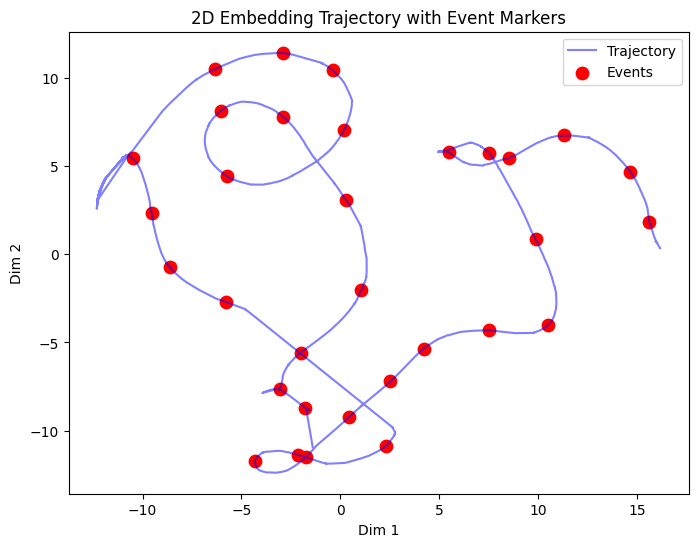

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Go to folder
os.chdir(r"C:\Users\Alishba\Downloads\prediction files\Transcriptions\Trajectory Analysis\k50 embeddings")

# Load one participant’s data
trajectory = np.load("delayed-trajectory.npy")  # (timepoints, 2)
events = np.load("delayed-events.npy")          # (num_events, 2)

print("Trajectory contains:", trajectory[:,:])
print("Trajectory shape:", trajectory.shape)
print("Events shape:", events.shape)

# Plot trajectory
plt.figure(figsize=(8,6))
plt.plot(trajectory[:,0], trajectory[:,1], color="blue", alpha=0.5, label="Trajectory")

# Overlay events as red dots
plt.scatter(events[:,0], events[:,1], color="red", s=80, label="Events")

plt.title("2D Embedding Trajectory with Event Markers")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.show()

### Connecting Events 

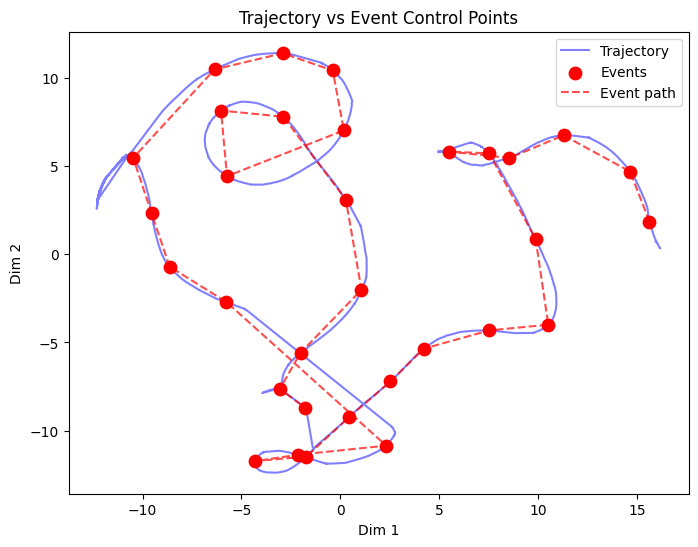

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Load data (example with delayed trajectory)
trajectory = np.load("delayed-trajectory.npy")
events = np.load("delayed-events.npy")

plt.figure(figsize=(8,6))

# Plot full trajectory
plt.plot(trajectory[:,0], trajectory[:,1], color="blue", alpha=0.5, label="Trajectory")

# Plot event points
plt.scatter(events[:,0], events[:,1], color="red", s=80, zorder=3, label="Events")

# Connect event points in order
plt.plot(events[:,0], events[:,1], color="red", linestyle="--", alpha=0.7, label="Event path")

plt.title("Trajectory vs Event Control Points")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.legend()
plt.show()

### Three-point window Algorithm (TRY #1)

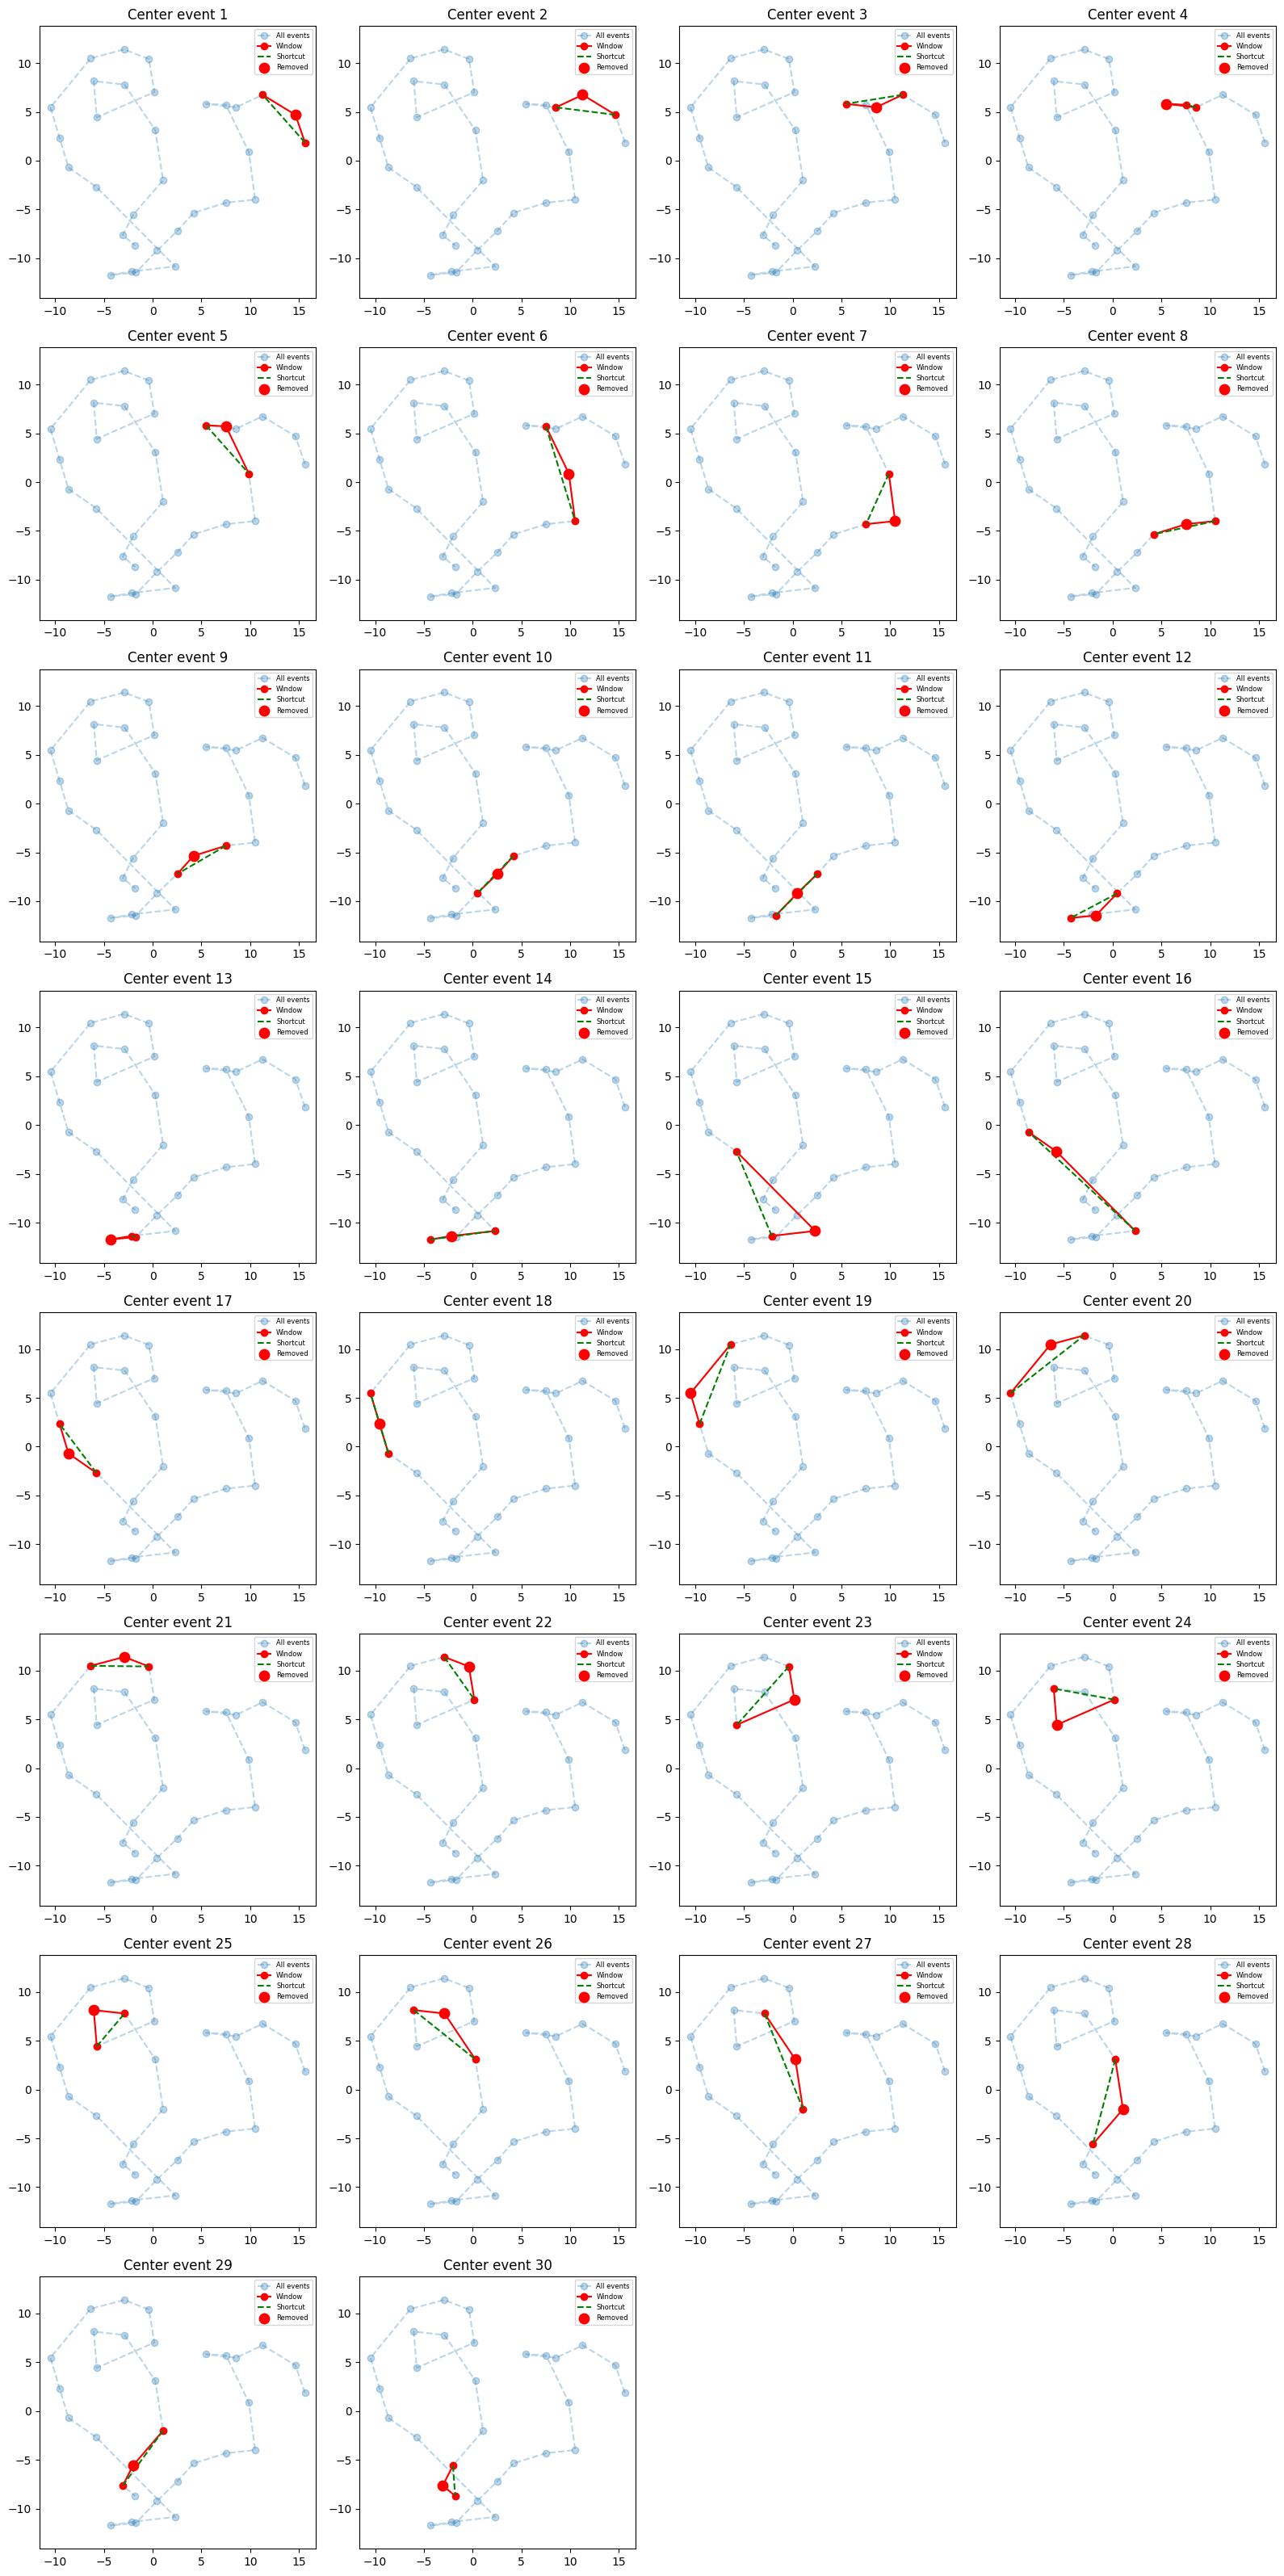

Event-wise differences:
Event 1: diff=0.4017, significant=True
Event 2: diff=0.8154, significant=True
Event 3: diff=0.2359, significant=True
Event 4: diff=4.0871, significant=True
Event 5: diff=0.8144, significant=True
Event 6: diff=0.1313, significant=True
Event 7: diff=2.2116, significant=True
Event 8: diff=0.0304, significant=False
Event 9: diff=0.2074, significant=True
Event 10: diff=0.0033, significant=False
Event 11: diff=0.0011, significant=False
Event 12: diff=0.3515, significant=True
Event 13: diff=4.3484, significant=True
Event 14: diff=0.0018, significant=False
Event 15: diff=6.5669, significant=True
Event 16: diff=0.0436, significant=False
Event 17: diff=0.3677, significant=True
Event 18: diff=0.0000, significant=False
Event 19: diff=1.0068, significant=True
Event 20: diff=0.4426, significant=True
Event 21: diff=0.3016, significant=True
Event 22: diff=0.7994, significant=True
Event 23: diff=1.8647, significant=True
Event 24: diff=3.8737, significant=True
Event 25: diff=2.48

In [ ]:
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt

def shape_change_with_event_removal(events, threshold=0.01, visualize=False):
    """
    Sliding 3-point window: check how removing the middle point
    changes the shape of the path between events.

    Parameters
    ----------
    events : np.ndarray
        Array of shape (N, D) where N = number of events, D = embedding dimensions
    threshold : float
        Minimum difference to consider event as influencing shape
    visualize : bool
        If True, plot each 3-point window comparison

    Returns
    -------
    changes : list of dict
        Each entry has:
        - index (middle event index)
        - path_via (length with middle point)
        - shortcut (length without middle point)
        - diff (absolute difference)
        - is_significant (True if diff > threshold)
    """
    
    # Control Point Detection Algorithm
    changes = []
    for i in range(1, len(events)-1):
        p1, p2, p3 = events[i-1], events[i], events[i+1]

        # Distance if middle point is removed
        shortcut = norm(p3 - p1)

        # Distance via middle point
        path_via = norm(p2 - p1) + norm(p3 - p2)

        # Difference
        diff = abs(path_via - shortcut)

        changes.append({
            "index": i,
            "path_via": path_via,
            "shortcut": shortcut,
            "diff": diff,
            "is_significant": diff > threshold
        })

    # visualization for 2D embeddings
    if visualize and events.shape[1] == 2:
        num_plots = len(events) - 2  # number of triplets
        cols = 4                     # number of mini-plots per row
        rows = int(np.ceil(num_plots / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
        axes = axes.flatten()
        
    for i in range(1, len(events)-1):
        p1, p2, p3 = events[i-1], events[i], events[i+1]

        ax = axes[i-1]
        ax.plot(events[:,0], events[:,1], 'o--', alpha=0.3, label="All events")
        ax.plot([p1[0], p2[0], p3[0]], [p1[1], p2[1], p3[1]], 'ro-', label="Window")
        ax.plot([p1[0], p3[0]], [p1[1], p3[1]], 'g--', label="Shortcut")
        ax.scatter(p2[0], p2[1], color="red", s=80, zorder=5, label="Removed")

        ax.set_title(f"Center event {i}")
        ax.axis("equal")
        ax.legend(fontsize=6)

    # remove unused subplot slots
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()  
    
    return changes


# Run on delayed-events file
events = np.load("delayed-events.npy")

results = shape_change_with_event_removal(events, threshold=0.05, visualize=True)

# Quick summary
print("Event-wise differences:")
for r in results:
    print(f"Event {r['index']}: diff={r['diff']:.4f}, significant={r['is_significant']}")


### Trajectory Comparison (In progress)

In [15]:
# import numpy as np
# from numpy.linalg import norm
# import matplotlib.pyplot as plt

# def segment_indices(trajectory, event_points):
#     """
#     Find the closest trajectory indices to each event point.
#     Assumes events are sampled from trajectory space.
#     """
#     indices = []
#     for ev in event_points:
#         dists = norm(trajectory - ev, axis=1)
#         indices.append(np.argmin(dists))
#     return indices


# def compare_event_to_trajectory(trajectory, events, threshold=0.01, visualize=False):
#     """
#     For each 3-event window, compare how well the middle event aligns with
#     the actual trajectory vs. skipping it (shortcut).
#     """
#     # Map each event to its closest trajectory index
#     event_to_traj_idx = segment_indices(trajectory, events)
#     changes = []

#     for i in range(1, len(events)-1):
#         idx1, idx2, idx3 = event_to_traj_idx[i-1], event_to_traj_idx[i], event_to_traj_idx[i+1]
#         p1, p2, p3 = trajectory[idx1], trajectory[idx2], trajectory[idx3]

#         # Full path length along trajectory (between idx1 and idx3)
#         traj_segment = trajectory[idx1:idx3+1]
#         traj_dist = np.sum(norm(np.diff(traj_segment, axis=0), axis=1))

#         # Shortcut distance (remove middle event)
#         shortcut = norm(p3 - p1)

#         diff = abs(traj_dist - shortcut)

#         changes.append({
#             "event_index": i,
#             "traj_dist": traj_dist,
#             "shortcut": shortcut,
#             "diff": diff,
#             "is_significant": diff > threshold
#         })

#         # Optional visualization (for 2D embeddings only)
#         if visualize and trajectory.shape[1] == 2:
#             plt.figure(figsize=(6,5))
#             plt.plot(trajectory[:,0], trajectory[:,1], color="blue", alpha=0.5, label="Trajectory")
#             plt.scatter(events[:,0], events[:,1], color="red", s=60, zorder=3, label="Events")
#             plt.plot([p1[0], p2[0], p3[0]], [p1[1], p2[1], p3[1]], 'ro--', label="3-event window")
#             plt.plot([p1[0], p3[0]], [p1[1], p3[1]], 'g--', label="Shortcut")
#             plt.scatter(p2[0], p2[1], color="red", s=100, marker="x", label="Removed event")
#             plt.title(f"Event {i} → diff={diff:.3f}")
#             plt.legend()
#             plt.show()

#     return changes


# # Example run
# trajectory = np.load("delayed-trajectory.npy")  # (timepoints, D)
# events = np.load("delayed-events.npy")          # (num_events, D)

# results = compare_event_to_trajectory(trajectory, events, threshold=0.05, visualize=True)

# print("Comparison results:")
# for r in results:
#     print(r)

### Global Shape Change Comparison

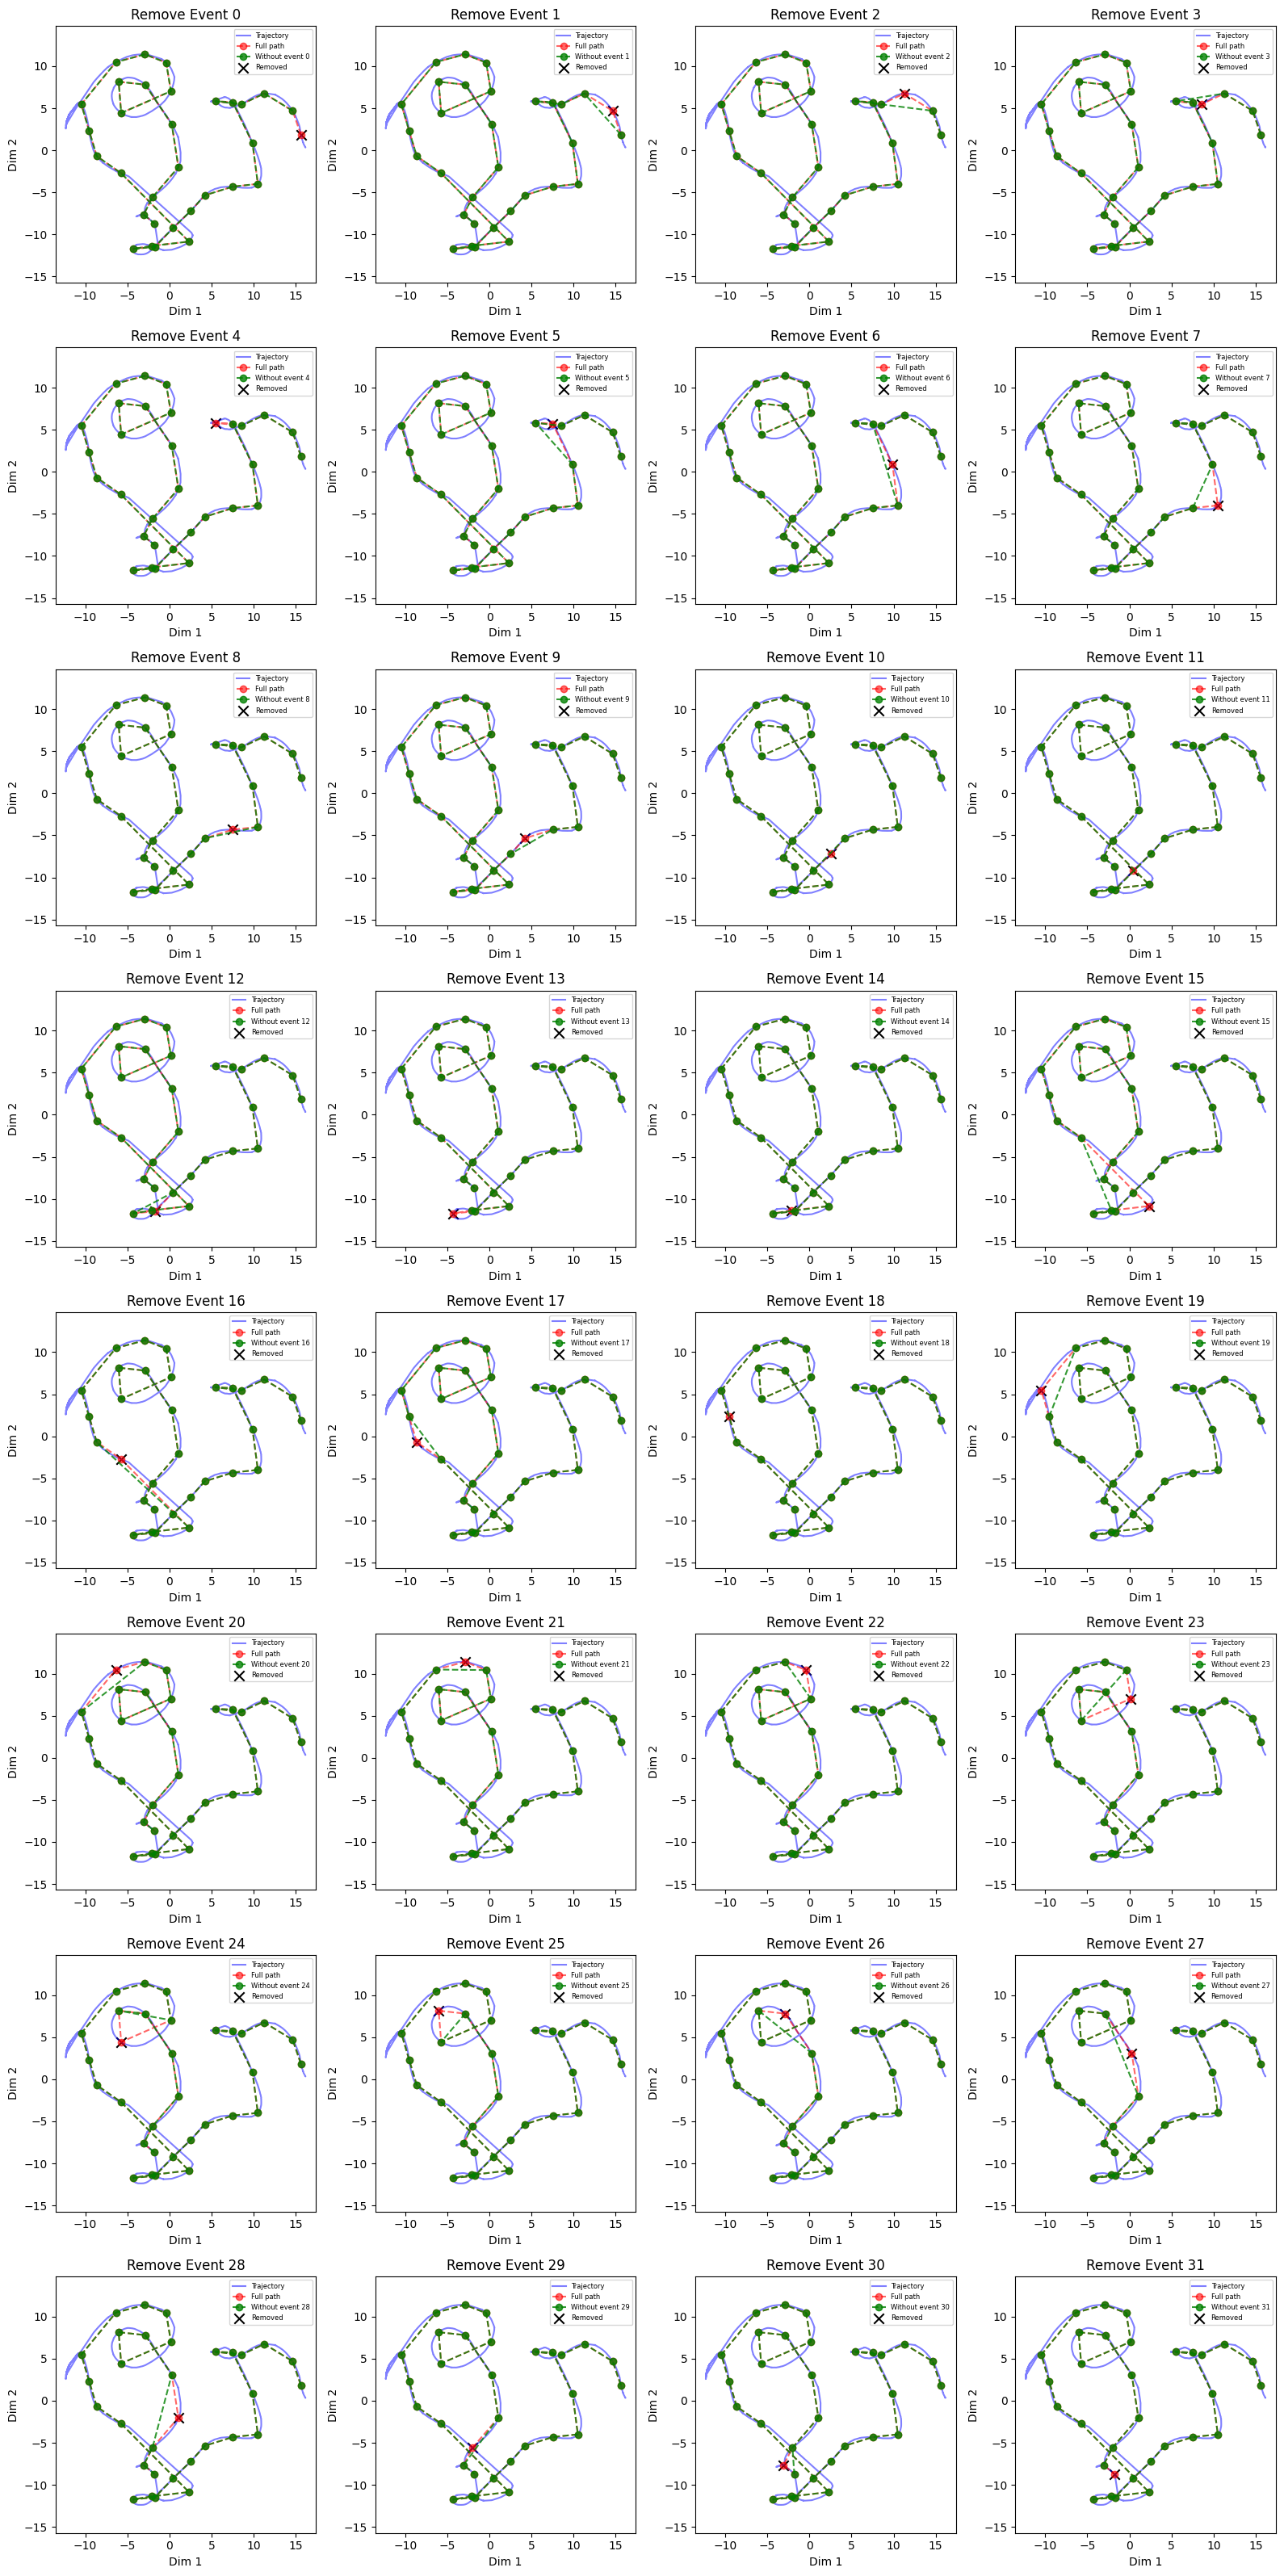

Summary of global shape changes:
{'removed_event': 0, 'reduced_path_len': np.float64(117.14256697586374), 'traj_len': np.float64(156.59193657734573), 'diff': np.float64(39.44936960148199)}
{'removed_event': 1, 'reduced_path_len': np.float64(119.74574831272416), 'traj_len': np.float64(156.59193657734573), 'diff': np.float64(36.846188264621574)}
{'removed_event': 2, 'reduced_path_len': np.float64(119.332112401157), 'traj_len': np.float64(156.59193657734573), 'diff': np.float64(37.25982417618873)}
{'removed_event': 3, 'reduced_path_len': np.float64(119.91156996357178), 'traj_len': np.float64(156.59193657734573), 'diff': np.float64(36.680366613773955)}
{'removed_event': 4, 'reduced_path_len': np.float64(116.0604205261037), 'traj_len': np.float64(156.59193657734573), 'diff': np.float64(40.531516051242036)}
{'removed_event': 5, 'reduced_path_len': np.float64(119.33309562107333), 'traj_len': np.float64(156.59193657734573), 'diff': np.float64(37.25884095627241)}
{'removed_event': 6, 'reduced_p

In [ ]:
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt

def path_length(points):
    """Compute total length of a path defined by sequential points."""
    return np.sum(norm(np.diff(points, axis=0), axis=1))

def shape_change_global(trajectory, events, visualize=True):
    """
    Remove each event one at a time, reconnect remaining events,
    and compare new path to trajectory.
    """
    base_path_len = path_length(events)  # original event path
    results = []

    for i in range(len(events)):
        # Remove event i
        reduced_events = np.delete(events, i, axis=0)

        # Path length with event removed
        reduced_path_len = path_length(reduced_events)

        # Difference wrt full trajectory
        traj_len = path_length(trajectory)
        diff = abs(reduced_path_len - traj_len)

        results.append({
            "removed_event": i,
            "reduced_path_len": reduced_path_len,
            "traj_len": traj_len,
            "diff": diff
        })

    if visualize and trajectory.shape[1] == 2:
        num_plots = len(events)
        cols = 4   # number of subplots per row
        rows = int(np.ceil(num_plots / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
        axes = axes.flatten()

    for i in range(len(events)):
        reduced_events = np.delete(events, i, axis=0)

        ax = axes[i]
        # Plot trajectory
        ax.plot(trajectory[:,0], trajectory[:,1], color="blue", alpha=0.5, label="Trajectory")
        # Full event path
        ax.plot(events[:,0], events[:,1], 'r--o', alpha=0.6, label="Full path")
        # Reduced path
        ax.plot(reduced_events[:,0], reduced_events[:,1], 'g--o', alpha=0.8, label="Without event {}".format(i))
        ax.scatter(events[i,0], events[i,1], color="black", s=80, marker="x", label="Removed")

        ax.set_title(f"Remove Event {i}")
        ax.set_xlabel("Dim 1")
        ax.set_ylabel("Dim 2")
        ax.axis("equal")
        ax.legend(fontsize=6)

    # remove unused subplot slots
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


    return results

# Example run
trajectory = np.load("delayed-trajectory.npy")  # (timepoints, D)
events = np.load("delayed-events.npy")          # (num_events, D)

results = shape_change_global(trajectory, events, visualize=True)

print("Summary of global shape changes:")
for r in results:
    print(r)
